# Topological Baseline
## What does calm S&P 500 topology look like?

Before detecting topological transitions, we need to establish a **baseline** — the typical topological signature of S&P 500 returns during calm, non-crisis periods.

We characterize the persistence diagrams, Betti curves, and $L^2$ norm during two calm periods:
- **2004-2006** — pre-GFC bull market
- **2012-2014** — post-GFC recovery, pre-volatility

This baseline is the reference against which crisis topology will be compared in Notebook 02.

In [2]:
import sys
import os

# Update this path to match your local tda-financial-data-pipeline location
sys.path.insert(0, os.path.expanduser('~/TDA-Gabo/tda-financial-data-pipeline'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import compute_log_returns, normalize
from src.embedding import takens_embedding
from src.data import fetch_ticker

# Load S&P 500
sp500 = fetch_ticker('^GSPC', '2000-01-01', '2024-01-01')
sp500.index = pd.to_datetime(sp500.index, utc=True).tz_localize(None)
sp500_r = normalize(compute_log_returns(sp500))

print(f"S&P 500: {len(sp500_r)} days")
print(f"Period: {sp500_r.index[0].date()} to {sp500_r.index[-1].date()}")

Loading from cache: ../data/raw/GSPC_2000-01-01_2024-01-01.csv
S&P 500: 6036 days
Period: 2000-01-04 to 2023-12-29


## Calm Period 1 — Pre-GFC Bull Market (2004-2006)

The S&P 500 was in a sustained bull market from 2004 to 2006 — low volatility, steady growth, no major shocks. This is our first baseline period.

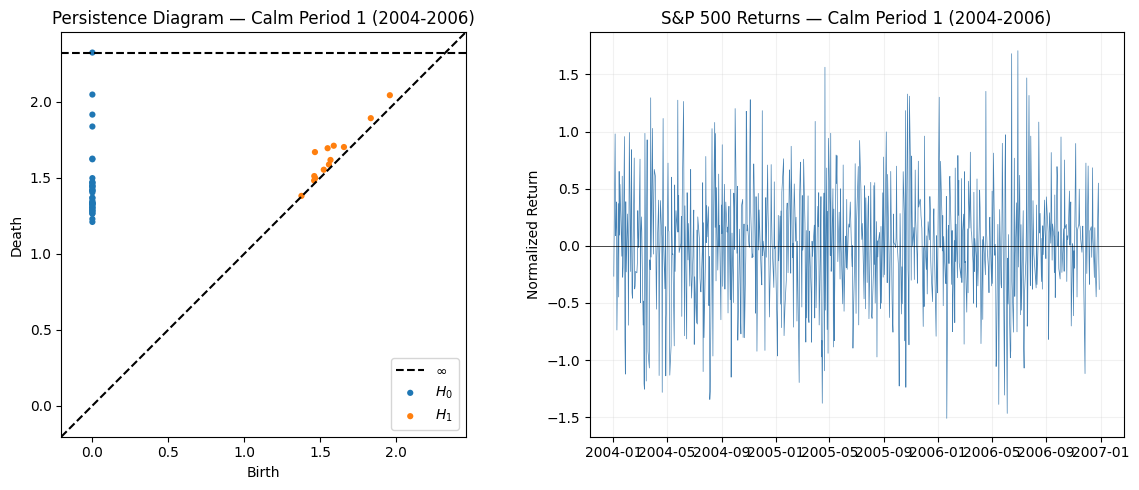

In [3]:
# Extract calm period 1: 2004-2006
calm1 = sp500_r['2004-01-01':'2006-12-31']

# Takens embedding (d=10, following Gidea & Katz)
d = 10
X_calm1 = takens_embedding(calm1.values[:50], d)

# Persistent homology
diagrams_calm1 = ripser(X_calm1)['dgms']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

# Persistence diagram
plot_diagrams(diagrams_calm1, ax=axes[0], show=False)
axes[0].set_title('Persistence Diagram — Calm Period 1 (2004-2006)')
axes[0].set_facecolor('white')

# Returns
axes[1].plot(calm1.index, calm1.values, color='steelblue', linewidth=0.5)
axes[1].set_title('S&P 500 Returns — Calm Period 1 (2004-2006)')
axes[1].set_ylabel('Normalized Return')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_facecolor('white')
axes[1].grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Calm Period 2 — Post-GFC Recovery (2012-2014)

A second calm period for comparison — the market had fully recovered from the GFC and was in a steady bull run with low volatility.

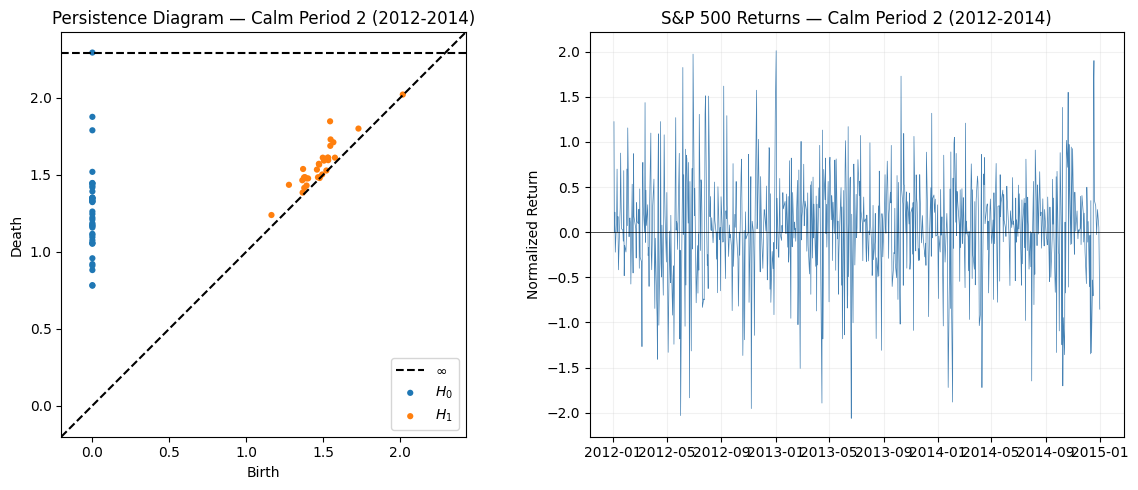

In [4]:
# Extract calm period 2: 2012-2014
calm2 = sp500_r['2012-01-01':'2014-12-31']

# Takens embedding
X_calm2 = takens_embedding(calm2.values[:50], d)

# Persistent homology
diagrams_calm2 = ripser(X_calm2)['dgms']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

plot_diagrams(diagrams_calm2, ax=axes[0], show=False)
axes[0].set_title('Persistence Diagram — Calm Period 2 (2012-2014)')
axes[0].set_facecolor('white')

axes[1].plot(calm2.index, calm2.values, color='steelblue', linewidth=0.5)
axes[1].set_title('S&P 500 Returns — Calm Period 2 (2012-2014)')
axes[1].set_ylabel('Normalized Return')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_facecolor('white')
axes[1].grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Baseline Characterization

Two calm periods, separated by 8 years, show remarkably consistent topology:

| Period | Filtration Scale | Max H1 Persistence | Character |
|--------|-----------------|-------------------|-----------|
| 2004-2006 | ~2.3 | ~0.2 | Compact, no significant loops |
| 2012-2014 | ~2.3 | ~0.3 | Compact, no significant loops |

**The topological baseline is stable** — calm S&P 500 returns consistently produce compact point clouds with diameter ~2.3 and no persistent H1 features.

This stability is what makes topological transitions detectable — when the market approaches a crisis, this compact structure breaks down dramatically, as we will see in Notebook 02.

## Betti Curves — Calm Baseline

Betti curves provide a functional summary of the topology across all filtration scales — complementing the persistence diagram with a continuous view of topological complexity.

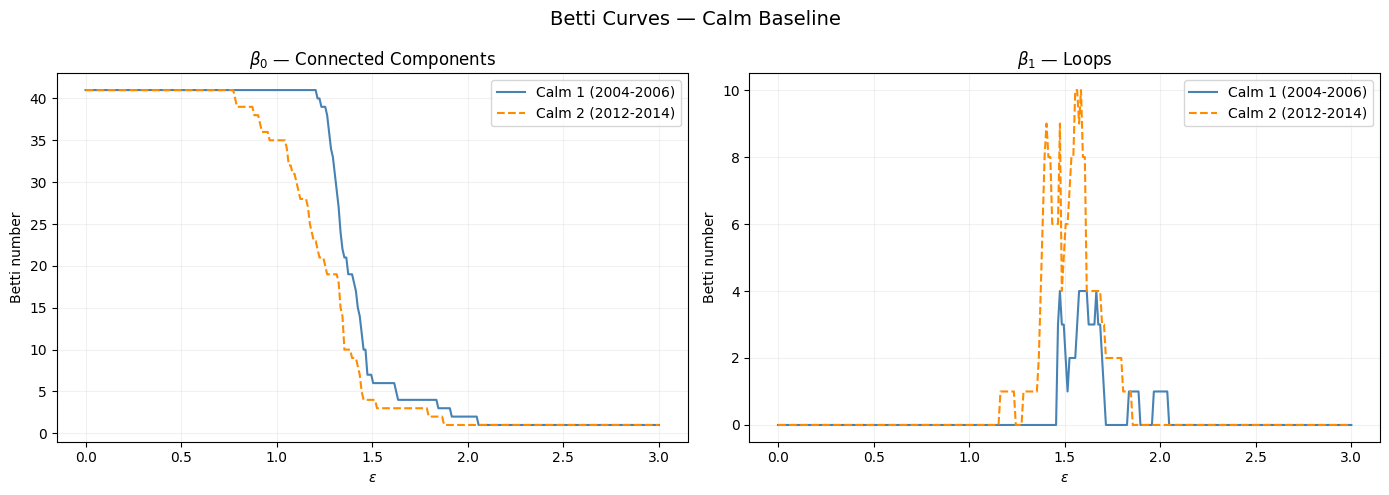

In [5]:
# Compute Betti curves for both calm periods
epsilons = np.linspace(0, 3, 300)

def betti(diagram, epsilon):
    return np.sum((diagram[:, 0] <= epsilon) & (diagram[:, 1] > epsilon))

beta0_calm1 = [betti(diagrams_calm1[0], e) for e in epsilons]
beta1_calm1 = [betti(diagrams_calm1[1], e) for e in epsilons]
beta0_calm2 = [betti(diagrams_calm2[0], e) for e in epsilons]
beta1_calm2 = [betti(diagrams_calm2[1], e) for e in epsilons]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

axes[0].plot(epsilons, beta0_calm1, color='steelblue', label='Calm 1 (2004-2006)')
axes[0].plot(epsilons, beta0_calm2, color='darkorange', label='Calm 2 (2012-2014)', linestyle='--')
axes[0].set_title('$\\beta_0$ — Connected Components')
axes[0].set_xlabel('$\\varepsilon$')
axes[0].set_ylabel('Betti number')
axes[0].legend()
axes[0].set_facecolor('white')
axes[0].grid(alpha=0.3, color='lightgrey')

axes[1].plot(epsilons, beta1_calm1, color='steelblue', label='Calm 1 (2004-2006)')
axes[1].plot(epsilons, beta1_calm2, color='darkorange', label='Calm 2 (2012-2014)', linestyle='--')
axes[1].set_title('$\\beta_1$ — Loops')
axes[1].set_xlabel('$\\varepsilon$')
axes[1].set_ylabel('Betti number')
axes[1].legend()
axes[1].set_facecolor('white')
axes[1].grid(alpha=0.3, color='lightgrey')

plt.suptitle('Betti Curves — Calm Baseline', fontsize=14)
plt.tight_layout()
plt.show()

## Observations

The Betti curves confirm the baseline characterization:

**$\beta_0$** — both periods merge to a single component, though at slightly different rates. Calm 2 (2012-2014) merges faster, suggesting a more tightly clustered point cloud.

**$\beta_1$** — both periods show short-lived loops that appear and disappear quickly. Calm 2 produces more transient loops (peak ~10 vs ~4) but none persist — all die before $\varepsilon = 2.0$.

**Baseline signature:** compact point cloud, no persistent H1 features, filtration scale ~2.3. Any significant deviation from this signature signals a topological transition.

## Euler Characteristic Curve

The Euler characteristic $\chi(\varepsilon) = \beta_0(\varepsilon) - \beta_1(\varepsilon)$ provides a scalar summary of topology at each filtration scale.

During calm periods we expect $\chi(\varepsilon)$ to be large and positive — dominated by $\beta_0$ as points connect into components. A **drop in $\chi$** signals loop formation ($\beta_1$ increasing) — a topological phase transition analogous to those observed in neuronal network dynamics.

We compute $\chi(\varepsilon)$ for both calm periods to establish the baseline Euler characteristic curve.

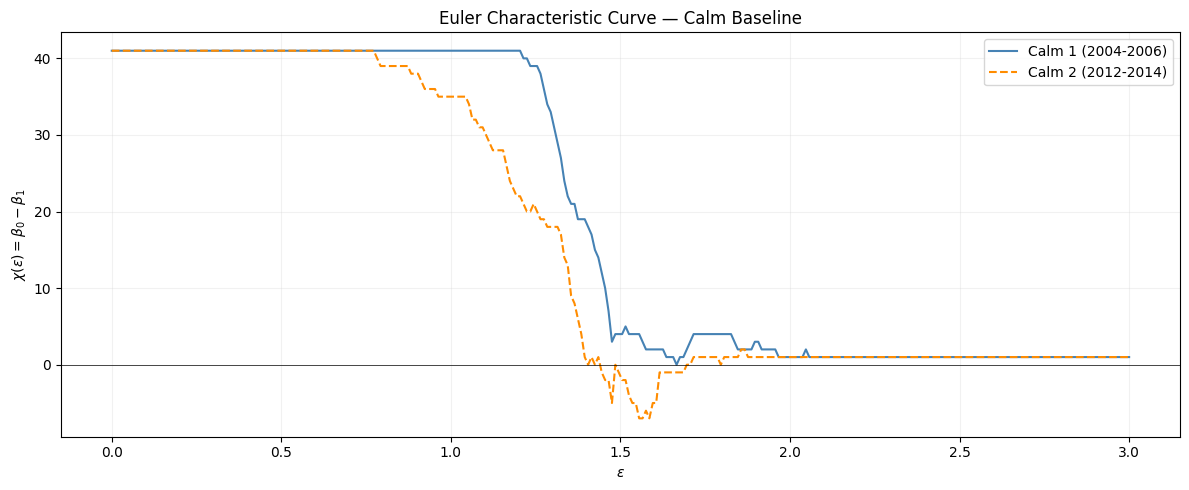

In [6]:
# Compute Euler characteristic curves
chi_calm1 = [b0 - b1 for b0, b1 in zip(beta0_calm1, beta1_calm1)]
chi_calm2 = [b0 - b1 for b0, b1 in zip(beta0_calm2, beta1_calm2)]

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')

ax.plot(epsilons, chi_calm1, color='steelblue', label='Calm 1 (2004-2006)')
ax.plot(epsilons, chi_calm2, color='darkorange', label='Calm 2 (2012-2014)', linestyle='--')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Euler Characteristic Curve — Calm Baseline')
ax.set_xlabel('$\\varepsilon$')
ax.set_ylabel('$\\chi(\\varepsilon) = \\beta_0 - \\beta_1$')
ax.legend()
ax.set_facecolor('white')
ax.grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Observations

The Euler characteristic curves reveal a key difference between the two calm periods:

- **Calm 1 (2004-2006)** — $\chi(\varepsilon)$ drops smoothly and monotonically to 1, never going negative. No significant loop formation.
- **Calm 2 (2012-2014)** — $\chi(\varepsilon)$ briefly goes negative around $\varepsilon \approx 1.5$, reflecting the transient loops seen in the $\beta_1$ curve. Recovers quickly to 1.

**Baseline signature:** $\chi(\varepsilon)$ converges to 1 with at most brief, shallow negative excursions. 

In Notebook 02, we expect crisis periods to show **deeper and more sustained negative values** of $\chi$ — a topological phase transition analogous to those observed in neuronal network dynamics during state transitions.

## Observations

The Betti curves confirm the baseline characterization:

**$\beta_0$** — both periods merge to a single component, though at slightly different rates. Calm 2 (2012-2014) merges faster, suggesting a more tightly clustered point cloud.

**$\beta_1$** — both periods show short-lived loops that appear and disappear quickly. Calm 2 produces more transient loops (peak ~10 vs ~4) but none persist — all die before $\varepsilon = 2.0$.

**Baseline signature:** compact point cloud, no persistent H1 features, filtration scale ~2.3. Any significant deviation from this signature signals a topological transition.